In [1]:
import pint

from jablonski import (
    SingletState,
    SpectroscopicSystem,
    initial,
    transitions,
)
from jablonski.simulation import (
    emission_spectra,
    excitation_spectra,
    graph_spectra,
    widened_emission_spectra,
)

u = pint.get_application_registry()
E0 = -13.6 * u.eV


class Hydrogen(SpectroscopicSystem):
    n2: SingletState = initial(E0 / 2**2, "singlet", default=1)
    n3: SingletState = initial(E0 / 3**2, "singlet", default=0)
    n4: SingletState = initial(E0 / 4**2, "singlet", default=0)
    n5: SingletState = initial(E0 / 5**2, "singlet", default=0)
    n6: SingletState = initial(E0 / 6**2, "singlet", default=0)

    absorption_1 = transitions.Absorption(ground=n2, excited=n3, rate=1.6e20 / u.s)
    absorption_2 = transitions.Absorption(ground=n2, excited=n4, rate=3.3e19 / u.s)
    absorption_3 = transitions.Absorption(ground=n2, excited=n5, rate=1.2e19 / u.s)
    absorption_4 = transitions.Absorption(ground=n2, excited=n6, rate=5.7e18 / u.s)
    emission_1 = transitions.Fluorescence(ground=n2, excited=n3, rate=4.4e7 / u.s)
    emission_2 = transitions.Fluorescence(ground=n2, excited=n4, rate=8.4e6 / u.s)
    emission_3 = transitions.Fluorescence(ground=n2, excited=n5, rate=3.2e6 / u.s)
    emission_4 = transitions.Fluorescence(ground=n2, excited=n6, rate=1.5e7 / u.s)

NameError: cannot rename ground to _source

In [2]:
# Steady state spectra with at a certain constant excitation
spectra = emission_spectra(
    Hydrogen,
    [
        Hydrogen.absorption_1,
        Hydrogen.absorption_2,
        Hydrogen.absorption_3,
        Hydrogen.absorption_4,
    ],
    height=10,
)
# spectra.to_dataframe().plot(style="--.")
spectra

c:\Users\olive\dyscolab\u2602\.pixi\envs\default\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


Magnitude,[13681136.24663343 2821734.350818105 1026085.2181260772 487390.47884559876]
Units,nanometer


c:\Users\olive\dyscolab\u2602\.pixi\envs\default\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


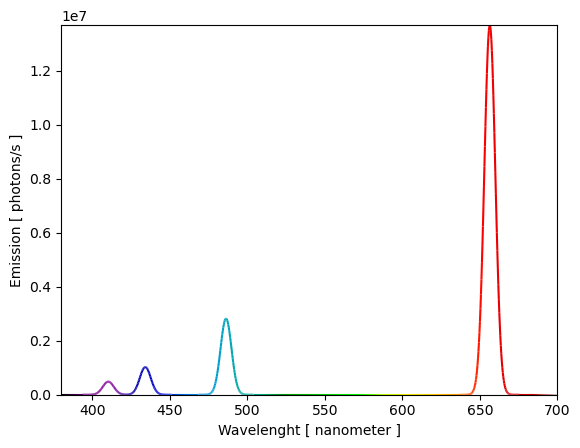

In [3]:
# Graph spectra with an arbitrary linewidth
fig, ax = graph_spectra(
    Hydrogen,
    [
        Hydrogen.absorption_1,
        Hydrogen.absorption_2,
        Hydrogen.absorption_3,
        Hydrogen.absorption_4,
    ],
    height=10,
)

In [4]:
# We can get the points in the graph with widened_emission_spectra
widened_emission_spectra(
    Hydrogen,
    [
        Hydrogen.absorption_1,
        Hydrogen.absorption_2,
        Hydrogen.absorption_3,
        Hydrogen.absorption_4,
    ],
    height=10,
)

<xarray.DataArray 'spectrum' (wavelenght: 1000)> Size: 8kB
<Quantity([6.31241454e-011 1.36450927e-010 2.92544946e-010 6.22076569e-010
 1.31198908e-009 2.74442731e-009 5.69388088e-009 1.17165609e-008
 2.39126147e-008 4.84048759e-008 9.71821022e-008 1.93516767e-007
 3.82195919e-007 7.48666886e-007 1.45454224e-006 2.80284565e-006
 5.35682132e-006 1.01543066e-005 1.90909930e-005 3.55993360e-005
 6.58400891e-005 1.20774168e-004 2.19731761e-004 3.96503247e-004
 7.09636254e-004 1.25967925e-003 2.21778421e-003 3.87269892e-003
 6.70723178e-003 1.15214736e-002 1.96294384e-002 3.31698002e-002
 5.55920858e-002 9.24098395e-002 1.52355661e-001 2.49134637e-001
 4.04058976e-001 6.49965851e-001 1.03698256e+000 1.64092035e+000
 2.57536437e+000 4.00889792e+000 6.18937000e+000 9.47770152e+000
 1.43944390e+001 2.16831109e+001 3.23954169e+001 4.80043604e+001
 7.05525860e+001 1.02844322e+002 1.48690367e+002 2.13216340e+002
 3.03244733e+002 4.27760996e+002 5.98472545e+002 8.30467066e+002
 1.14297237e+003 1.56021404e+003 2.11235917e+003 2.83652411e+003
 3.77781190e+003 4.99033055e+003 6.53812818e+003 8.49596434e+003
 1.09498221e+004 1.39970522e+004 1.77460309e+004 2.23152120e+004
 2.78314564e+004 3.44275395e+004 4.22387609e+004 5.13986233e+004
 6.20335932e+004 7.42570210e+004 8.81623668e+004 1.03815952e+005
 1.21249534e+005 1.40453057e+005 1.61368012e+005 1.83881837e+005
...
 2.05850034e+001 1.28239019e+001 7.92363689e+000 4.85583674e+000
 2.95147236e+000 1.77929721e+000 1.06388187e+000 6.30918780e-001
 3.71098016e-001 2.16490550e-001 1.25263456e-001 7.18861075e-002
 4.09167076e-002 2.30989121e-002 1.29335428e-002 7.18254932e-003
 3.95616924e-003 2.16125615e-003 1.17104276e-003 6.29324153e-004
 3.35437165e-004 1.77330359e-004 9.29801278e-005 4.83539902e-005
 2.49407570e-005 1.27591598e-005 6.47395473e-006 3.25800969e-006
 1.62618600e-006 8.05050639e-007 3.95285891e-007 1.92501696e-007
 9.29807277e-008 4.45437170e-008 2.11648455e-008 9.97421862e-009
 4.66205935e-009 2.16128404e-009 9.93758890e-010 4.53195242e-010
 2.04986278e-010 9.19600865e-011 4.09174996e-011 1.80573466e-011
 7.90376314e-012 3.43122369e-012 1.47740403e-012 6.30935063e-013
 2.67242286e-013 1.12269252e-013 4.67790729e-014 1.93320329e-014
 7.92389251e-015 3.22132660e-015 1.29887116e-015 5.19436573e-016
 2.06031729e-016 8.10533229e-017 3.16258840e-017 1.22391049e-017
 4.69777026e-018 1.78841797e-018 6.75276146e-019 2.52888410e-019
 9.39315689e-020 3.46042436e-020 1.26439357e-020 4.58216083e-021
 1.64699967e-021 5.87153739e-022 2.07608572e-022 7.28071224e-023
 2.53243079e-023 8.73647898e-024 2.98930633e-024 1.01447077e-024
 3.41463110e-025 1.13994311e-025 3.77448493e-026 1.23955941e-026], 'nanometer')>
Coordinates:
  * wavelenght  (wavelenght) float64 8kB 380.0 380.3 380.6 ... 699.4 699.7 700.0

In [5]:
# Excitation spectra, calculates steady state emission spectra when exciting all pumpers (one at a time)
# with specified height
excitation_spectra(Hydrogen, height=2)

c:\Users\olive\dyscolab\u2602\.pixi\envs\default\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\olive\dyscolab\u2602\.pixi\envs\default\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\olive\dyscolab\u2602\.pixi\envs\default\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\olive\dyscolab\u2602\.pixi\envs\default\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


Magnitude,[43999999.99999392 0.0 0.0 0.0]
Units,nanometer
Magnitude,[0.0 8399999.999998933 0.0 0.0]
Units,nanometer
Magnitude,[0.0 0.0 3199999.999999572 0.0]
Units,nanometer
Magnitude,[0.0 0.0 0.0 14999999.999980262]
Units,nanometer
